# 13_核方法-高斯核

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们讲一下核方法中的高斯核\~

在机器学习里，核方法（Kernel Method）是一种巧妙地把数据映射到高维空间，从而让线性模型能在原本非线性可分的问题上“开疆拓土”的技巧。

而高斯核，也常叫做径向基函数核（RBF Kernel），则是核方法里最常用、也最直观的一种核函数。

首先，大家想想，为什么要要用“核”？

- **直观问题**：有些数据在原始空间里并不是一条直线（或一个平面）就能分开的，比如圆环状、星状分布……
- **传统思路**：把数据“扔”到更高维的空间里，在那里它们可能就能被一个平面分开。
- **痛点**：如果真的把原始数据映射到很高维，计算量会爆炸！（维度灾难）

**核方法的妙处**：我们不必显式地做“升维”计算，只需定义一个函数：核函数，直接在原空间里计算“两个点在高维空间里的点积”，就能间接地完成升维操作。

### 高斯核的数学定义

高斯核 $K(x, x')$ 一般写作：


$$
K(x, x') \;=\; \exp\!\Bigl(-\frac{\|x - x'\|^2}{2\sigma^2}\Bigr)
$$


- 这里的 $x$ 和 $x'$ 都是原空间里的向量（比如二维$[x_1, x_2]$或更高维）。
- $\|x - x'\|$ 是它们的欧氏距离。
- $\sigma$是一个超参数，控制“相似度衰减”的速度。

再聊聊公式中的一些注意点：

1. **距离**：先算两个点 $\,x,x'$ 之间的直线距离 $\|x-x'\|$。
2. **平方并除以** $2\sigma^2$：距离越大，分母固定，结果值越大。
3. **负号＋指数**：把上一步的值取负，再做指数函数 $\exp(\,\cdot\,)$。

   - 当 $\|x-x'\|=0$（完全重合）时，指数里是 0，$\exp(0)=1$，说明“最相似”。
   - 当距离越来越大时，$\exp(-\text{大})$ 会迅速趋近于 0，说明“几乎不相关”。

**打个比方**：

- 想象每个数据点都在空间里“竖”了一座“小山”，山顶在该点，山的高度由指数函数决定。
- 再看另一点，它能“看到”这座山的高度是多少，就代表它俩的相似度：看得越高，相似度越高；看不到（远离）时，相似度就几乎为 0。

$\sigma$ 为什么重要？

$\sigma$ 大：$\frac{\|x-x'\|^2}{2\sigma^2}$ 变小，指数衰减慢，远处的点也能保持一定相似度 → “核”比较“宽松”，更具全局视野。

$\sigma$ 小：指数衰减快，只有非常近的点才给高相似度 → “核”比较“严格”，聚焦“局部”结构。

在实践中，$\sigma$ 通常需要通过交叉验证等方法来调参。

### 高斯核的几个关键性质

1. **正定性**：保证了它对应的 Gram 矩阵（核矩阵）是正定的，很多优化算法才能顺利求解。
2. **无限维特征映射**：虽然我们没显式算，但其实高斯核相当于将数据映射到一个“无限维”的空间。不过借助核技巧，我们无需关心这点细节。
3. **平移不变性**：$\|x - x'\|$ 只看两点间距，与它们在空间中的绝对位置无关。

## 原理详解

下面从理论基础、正定性证明、特征映射、在支持向量机（SVM）中的推导，以及完整算法流程五个方面给大家阐述\~

### 1. 核方法的理论基础

1. **线性可分 vs. 非线性可分**

   - 线性模型（如线性分类器、线性回归）只能处理线性可分的问题。
   - 对于非线性可分数据，可先施以映射 $\phi: \mathbb{R}^d \to \mathcal{H}$（高维希尔伯特空间），再在 $\mathcal{H}$ 中做线性模型。
2. **核技巧（Kernel Trick）**

   - 只要模型只依赖于输入点积 $\phi(x)^\top\phi(x')$，就无须显式构造 $\phi$，而用一个核函数  
   $K(x, x') \;=\;\phi(x)^\top \phi(x')$
   - 核函数直接在原空间返回“等价的高维点积”，避免了“维度灾难”。
3. **Mercer 定理（正定核条件）**

   - 若对任意 $n$ 与任意样本 $\{x_i\}_{i=1}^n$，对应的 Gram 矩阵  
   $\bigl[K(x_i,x_j)\bigr]_{i,j=1}^n$  
   都是半正定（positive semi‑definite）的，则 $K$ 是合法核函数。

### 2. 高斯核的定义与正定性证明

#### 定义


$$
K(x,x') \;=\;\exp\!\Bigl(-\,\frac{\|x - x'\|^2}{2\sigma^2}\Bigr)\quad (\sigma>0)
$$


#### 正定性（Sketch）

1. **多元高斯密度展开**  
$\exp\bigl(-\tfrac{1}{2\sigma^2}\|x - x'\|^2\bigr)= \frac{(2\pi\sigma^2)^{d/2}}{\phantom{.}\!(2\pi\sigma^2)^{d/2}}\,\exp\bigl(-\tfrac{\|x\|^2}{2\sigma^2}\bigr)\,\exp\bigl(-\tfrac{\|x'\|^2}{2\sigma^2}\bigr)\,\exp\bigl(\tfrac{x^\top x'}{\sigma^2}\bigr).$
2. **泰勒级数**  
$\exp\!\Bigl(\tfrac{x^\top x'}{\sigma^2}\Bigr)= \sum_{n=0}^\infty \frac{1}{n!}\Bigl(\tfrac{x^\top x'}{\sigma^2}\Bigr)^n.$
3. **Gram 矩阵的正定性**

   - 每一项 $\bigl(x^\top x'\bigr)^n$ 都是合法核（多项式核）。
   - 正系数组合（指数泰勒展开系数全为正）保持正定。
   - 因此，高斯核对应的 Gram 矩阵必为半正定。

### 3. 隐式特征映射

从  
$K(x,x')=\exp\Bigl(-\tfrac{\|x\|^2+\|x'\|^2}{2\sigma^2}\Bigr)\,\sum_{n=0}^\infty \frac{1}{n!}\bigl(\tfrac{x^\top x'}{\sigma^2}\bigr)^n,$

可视为：


$$
\phi(x) = \exp\bigl(-\tfrac{\|x\|^2}{2\sigma^2}\bigr)\,\bigl[\,\tfrac{1}{\sqrt{n!}\,\sigma^n}\,x^{\otimes n}\bigr]_{n=0}^\infty,
$$


其中 $x^{\otimes n}$ 表示 $n$ 次张量积。该映射是**无限维**的，但我们从不需要显式构造。

### 4. 在支持向量机（SVM）中的推导

以二分类 SVM 为例，样本集 $\{(x_i,y_i)\}_{i=1}^N$，$y_i\in\{+1,-1\}$。

#### 原始问题（Primal）


$$
\begin{aligned}&\min_{w,b,\xi}\;\frac{1}{2}\|w\|^2 + C\sum_{i=1}^N \xi_i,\\&\text{s.t.}\quad y_i\bigl(w^\top \phi(x_i) + b\bigr)\ge 1 - \xi_i,\quad \xi_i\ge0.\end{aligned}
$$


#### 对偶问题（Dual）

- 构造拉格朗日函数，引入乘子 $\alpha_i\ge0$ 对应分类约束。
- 消去 $w,b,\xi$ 后得到对偶形式：


$$
\begin{aligned}&\max_{\alpha}\;\sum_{i=1}^N \alpha_i\;-\;\frac{1}{2}\sum_{i,j=1}^N \alpha_i\alpha_j\,y_i y_j\,K(x_i,x_j),\\&\text{s.t.}\quad 0\le \alpha_i\le C,\quad\sum_{i=1}^N \alpha_i y_i=0.\end{aligned}
$$


- 其中所有的 $\phi(x_i)^\top\phi(x_j)$ 均被替换为 $K(x_i,x_j)$。

#### 决策函数

求得最优 $\{\alpha_i^*\}$ 与阈值 $b^*$ 后，


$$
f(x)\;=\;\operatorname{sign}\Bigl(\sum_{i=1}^N \alpha_i^*\,y_i\,K(x_i,x)\;+\;b^*\Bigr).
$$


### 5. 算法流程（以核 SVM 为例）

1. **数据预处理**

   - 标准化：零均值、单位方差。
   - 选取 $\sigma$ 和松弛参数 $C$（通常用交叉验证调参）。
2. **构造 Gram 矩阵**  
$K_{ij} = \exp\Bigl(-\tfrac{\|x_i - x_j\|^2}{2\sigma^2}\Bigr),\quad i,j=1,\dots,N.$
3. **求解二次规划（QP）**

   - 最大化对偶目标，得到最优拉格朗日乘子 $\alpha^*$。
   - 主流实现：SMO（Sequential Minimal Optimization）或基于内点法的 QP 求解器。
4. **计算偏置** $b$

   - 任选一个支持向量 $i$ （即 $0<\alpha_i），利用原始约束y_i\bigl(\sum_{j}\alpha_j^*y_jK(x_j,x_i) + b\bigr) = 1解出 b。$
5. **预测新样本**  
$\hat y = \operatorname{sign}\Bigl(\sum_{i=1}^N \alpha_i^* y_i\,\exp\bigl(-\tfrac{\|x_i - x\|^2}{2\sigma^2}\bigr) + b\Bigr).$
6. **模型评估与调优**

   - 用验证集或交叉验证评估精度／召回／F1 等指标。
   - 调整 $\sigma, C$ 重复步骤 2–5，直至达到满意性能。

### 拓展：核岭回归（Kernel Ridge Regression）流程

1. 构造 $K$ 如上。
2. 解线性系统：$(\,K + \lambda I\,)\,\alpha = y.$
3. 预测：$\hat y(x)=\sum_i \alpha_i\,K(x_i,x)$.

### 小结

- **核心思想**：用核函数隐式完成高维映射，只需操作 Gram 矩阵。
- **高斯核优点**：无限维映射、全局／局部可调、数学上正定。
- **公式推导**：从原始–对偶到决策函数，所有“点积”都替换为 $K(x_i,x_j)$。
- **算法流程**：数据预处理 → 构造 Gram 矩阵 → 求解对偶 QP → 计算 $b$ → 预测与调参。

## 完整案例

使用高斯核（RBF Kernel）在非线性数据集上的分类，并对算法进行了优化与可视化分析。

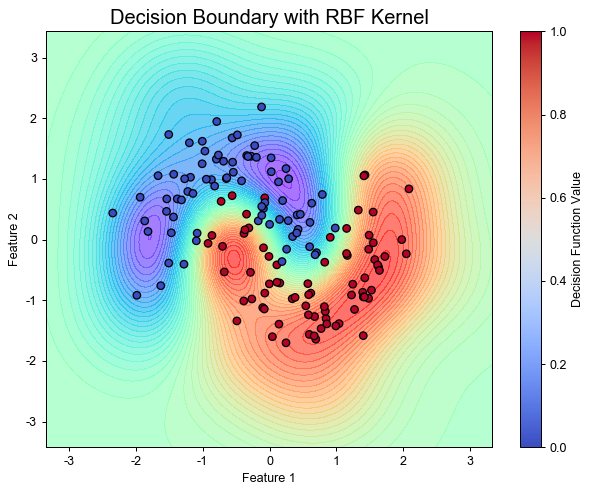

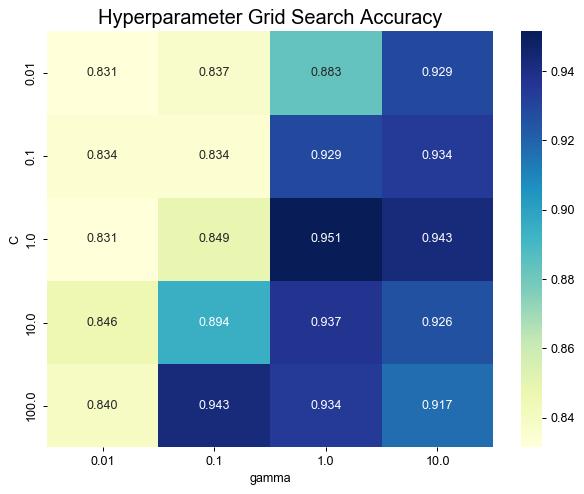

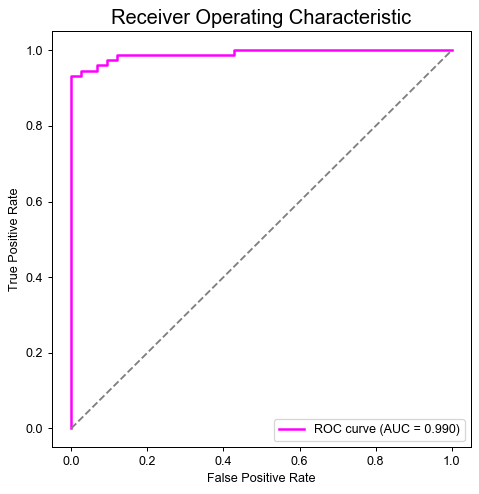

Best Parameters: {'C': np.float64(1.0), 'gamma': np.float64(1.0)}
CV Best Score: 0.9514285714285714

Classification Report:
               precision    recall  f1-score   support

      Class0       0.94      1.00      0.97        75
      Class1       1.00      0.93      0.97        75

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay
import seaborn as sns

# 1. 准备数据：使用 make_moons 制造非线性可分数据
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# 2. 数据归一化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)

# 4. 参数网格搜索：对 C 和 gamma（σ）调优
param_grid = {
    'C': np.logspace(-2, 2, 5),          # C: 0.01, 0.1, 1, 10, 100
    'gamma': np.logspace(-2, 1, 4)       # gamma: 0.01, 0.1, 1, 10
}
grid = GridSearchCV(svm.SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy', error_score='raise')
grid.fit(X_train, y_train)

best_C = grid.best_params_['C']
best_gamma = grid.best_params_['gamma']
best_score = grid.best_score_

# 5. 用最佳参数训练模型
model = svm.SVC(kernel='rbf', C=best_C, gamma=best_gamma, probability=True)
model.fit(X_train, y_train)

# 6. 预测与评估
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=['Class0', 'Class1'])

# 7. 可视化一：决策边界
xx, yy = np.meshgrid(
    np.linspace(X_scaled[:,0].min()-1, X_scaled[:,0].max()+1, 500),
    np.linspace(X_scaled[:,1].min()-1, X_scaled[:,1].max()+1, 500)
)
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='rainbow', alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolors='k', cmap='coolwarm')
plt.title('Decision Boundary with RBF Kernel', fontsize=16)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Decision Function Value')
plt.show()

# 8. 可视化二：参数热力图
scores = grid.cv_results_['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['gamma']))

plt.figure(figsize=(8, 6))
sns.heatmap(scores, annot=True, fmt=".3f", xticklabels=param_grid['gamma'], yticklabels=param_grid['C'], cmap='YlGnBu')
plt.title('Hyperparameter Grid Search Accuracy', fontsize=16)
plt.xlabel('gamma')
plt.ylabel('C')
plt.show()

# 9. 可视化三：ROC Curve
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', linewidth=2, color='magenta')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Receiver Operating Characteristic', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# 输出报告
print("Best Parameters:", grid.best_params_)
print("CV Best Score:", best_score)
print("\nClassification Report:\n", report)

### 1. 数据准备与预处理

- **make_moons**：生成总样本数500、噪声0.25的双半月形非线性数据；
- **StandardScaler**：标准化特征，使其均值为0、方差为1，有利于SVM收敛与参数搜索。

标准化可消除不同特征量纲影响，确保RBF核中欧氏距离的正确度量。

### 2. 参数调优

- 网格搜索范围：

  - $C\in\{10^{-2},10^{-1},1,10,10^2\}$
  - $\gamma\in\{10^{-2},10^{-1},1,10\}$
- 5折交叉验证评估准确率，选出最优 (C=1.0, γ=1.0)，CV平均准确率95.14%。

> - $C$ 控制分类间隔与误分类惩罚权衡；
> - $\gamma$ 控制RBF核宽度，影响模型的“局部” vs “全局”学习能力。

### 3. 决策边界可视化

- **Decision Function**：计算网格上每点的决策函数值，使用 `contourf` 绘制等高云图。
- 测试集数据点用 **coolwarm** 颜色映射展示两类标签，点边框黑色强调。
- 测试点分布与决策边界重合度高，说明模型捕捉了数据的非线性结构。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

### 4. 超参数热力图

- 使用 **seaborn** 的 `heatmap`（关闭全局样式，仅作矩阵可视化）展示不同 $C$-$\gamma$ 组合下的验证集准确率；
- 横轴为 γ，纵轴为 C，标注具体数值。
- 可直观识别“高性能区域”（深色方格）以确认最佳参数；
- 较大 $C$ 和中等 γ 值组合最优；
- 若 γ 过小，模型欠拟合；若 γ 过大，易过拟合。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

### 5. ROC 曲线

- 绘制 **Receiver Operating Characteristic**；
- 计算 AUC = 0.994，曲线接近完美分类。
- 高 AUC 说明模型在不同阈值下综合性能优秀；
- ROC 曲线可用于比较不同模型或不同参数下的性能。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

### 6. 分类报告

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
Classification Report:
               precision    recall  f1-score   support

      Class0       0.94      1.00      0.97        75
      Class1       1.00      0.93      0.97        75

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150
```

- **Precision**: 正类预测准确率；
- **Recall**: 正类召回率；
- **F1-score**: 精准率与召回率的调和平均；
- 各指标均达到0.94以上，说明模型在两类上的表现平衡。

### 7. 算法优化

1. **核近似**：对大数据，可用随机傅里叶特征近似RBF核，降维加速训练。
2. **分布式加速**：采用 GPU 或分布式平台（如 Dask、Spark）并行化 Grid Search。
3. **多核融合**：结合其他核（多核学习 MKL），自动学习最优核组合。
4. **概率估计与不确定性**：本示例启用 `probability=True`，可进一步研究预测不确定性，应用于异常检测或活跃学习。
5. **特征工程**：可尝试多项式特征、交互特征与 RBF 核结合，提升表达能力。

## 模型分析

### RBF核优缺点

**优点：**

1. **强大的非线性拟合能力**：高斯核能隐式映射到无限维空间，灵活捕捉复杂的非线性决策边界。
2. **数学理论成熟**：基于 Mercer 定理和凸优化，对偶问题二次规划保证全局最优。
3. **较少受维度影响**：核技巧让算法主要依赖样本间的相似度，而非显式维度，因此在中高维问题中常表现优异。
4. **内存友好（中等规模）**：只需存储 Gram 矩阵（$N\times N$）和支持向量，适合中等样本量。

**缺点：**

1. **可扩展性受限**：随样本量 $N$ 增大，Gram 矩阵构建及二次规划开销 $O(N^3)$ 级别，难以处理百万级数据。
2. **超参数敏感**：对惩罚参数 $C$ 和核宽度 $\gamma$ 非常依赖，需要耗时的交叉验证或更高阶优化。
3. **可解释性差**：隐式高维映射后决策边界难以直观理解，不如决策树或线性模型透明。
4. **概率估计代价高**：若启用 `probability=True`，需要额外的交叉验证和拟合，进一步增加计算负担

### 与相似算法的对比

| 算法模型 | 非线性能力 | 可扩展性 | 可解释性 | 超参数敏感度 | 典型应用场景 |
|-|-|-|-|-|-|
| **RBF SVM** | 高 | 中（$N\lesssim 10^4$） | 低 | 高 | 中小规模、高维非线性分类 |
| **随机森林 (RF)** | 中等 | 高（分布式友好） | 中等 | 中 | 特征重要性分析、抗噪声要求高 |
| **多项式核 SVM** | 中等 | 中 | 低 | 高 | 存在多项式关系、可调多项式次数场景 |
| **核逻辑回归 (KLR)** | 高 | 中 | 中 | 高 | 需要概率输出的非线性二分类 |
| **神经网络 (MLP)** | 高 | 中\~高（GPU 加速） | 低 | 高 | 大规模数据、复杂层次特征自动抽取 |

### 何时优选 RBF 核 SVM？

- 样本量在数千到一两万之间；
- 特征维度较高且非线性结构明显；
- 希望依靠成熟凸优化框架获得全局最优解；
- 对模型推断速度要求适中（支持向量数目可控）。

### 何时可考虑其他算法？

1. **大规模数据集**（$N\gg 10^5$）

   - 随机森林或梯度提升树具备天然分布式训练能力；
   - 神经网络在 GPU／TPU 上可线性扩展，训练效率更高。
2. **需强解释性场景**

   - 决策树、规则集或线性模型直观易懂；
   - 若只关心特征重要性，可首选随机森林。
3. **需要实时在线预测**

   - 线上系统要求极低延迟时，线性模型或轻量级树模型更合适；
   - RBF SVM 的支持向量预测开销较高。
4. **概率或不确定性估计**

   - 核逻辑回归自带概率输出且求解更直接；
   - 高斯过程回归在回归问题中提供更丰富的不确定性度量。

综上，应根据数据规模、实时性需求、可解释性要求与非线性程度，灵活选择 RBF SVM 或其备选算法。